# Inference using pre-trained model

## Full-Input Residual-Output Autoencoding with Projection Pursuit Encoders

# Progressive Multi-Scale Autoencoder

Inference tutorial for the `compressors.frappe` module (patchify approach). Finer-scale latents are rearranged to the coarsest resolution via einops, then all patchified latents are concatenated and fed through a single unified decoder.

In [1]:
import torch, datasets, numpy as np, matplotlib.pyplot as plt, io, PIL.Image, pillow_jpls
from compressors.frappe.model import MergedAutoencoder, load_progressive_model, load_from_hub
from compressors.frappe.ops import get_scale_groups, adapt_to_decoder, decoder_channels_per_encoder
from compressors.frappe.quantize import srgb_to_linear, make_quantizer
from torchvision.transforms.v2.functional import pil_to_tensor, to_pil_image

In [2]:
device = 'cuda:0'
dataset = datasets.load_dataset("danjacobellis/kodak", split='validation')

## Loading a checkpoint

Progressive checkpoints store per-channel-count snapshots: `merged_decoder_weights[n]` contains encoder weights (per scale group), decoder weights, scale group structure, and patchify factors for a model using the first `n+1` channels.

In [3]:
config, weights, n_trained = load_from_hub()
max_ps = max(config.ps[:n_trained])

print(f"Channels trained: {n_trained}")
print(f"Patch sizes: {config.ps[:n_trained]}")
print(f"Decoder ps: {config.decoder_ps}")

Channels trained: 21
Patch sizes: [32, 32, 32, 16, 16, 16, 16, 16, 16, 8, 8, 8, 4, 4, 4, 4, 4, 4, 2, 2, 2]
Decoder ps: 8


## Encoder filters

Each scale group has its own consolidated encoder. Display the learned filters per scale.

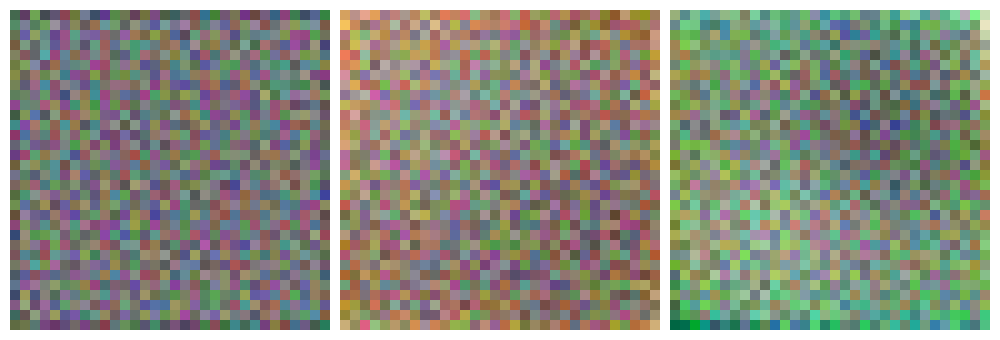

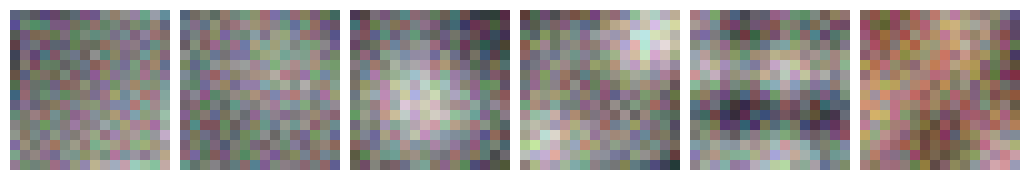

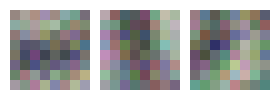

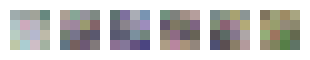

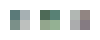

Filter std per scale (display range = ±4σ):
  p=32:  σ = 0.0117
  p=16:  σ = 0.0364
  p= 8:  σ = 0.0710
  p= 4:  σ = 0.2006
  p= 2:  σ = 0.3584


In [4]:
from compressors.frappe.visualize import make_filter_grid
import einops

merged = load_progressive_model(weights, config, n_trained, device)

# Compute per-scale std (the normalization range for display)
scale_stds = {}
for s, (ps_s, start, end) in enumerate(merged.scale_groups):
    n_ch_g = end - start
    filters = merged.encoders[s][0].weight.data.cpu()
    biases = merged.encoders[s][0].bias.data.cpu()
    grid = einops.rearrange(filters, '(H W) c h w -> H W c h w', H=1, W=n_ch_g)
    bias_grid = einops.rearrange(biases, '(H W) -> H W 1 1 1', H=1, W=n_ch_g)
    combined = grid + bias_grid / torch.prod(torch.tensor(filters.shape[-3:]))
    scale_stds[ps_s] = combined.std().item()

scale = 10

for s, (ps_s, start, end) in enumerate(merged.scale_groups):
    n_ch_g = end - start
    filters = merged.encoders[s][0].weight.data.cpu()
    biases = merged.encoders[s][0].bias.data.cpu()
    grid = make_filter_grid(filters, biases, n_ch_g, layout=(1, n_ch_g))
    w_px, h_px = grid.shape[2] * scale, grid.shape[1] * scale
    img = to_pil_image(grid).resize((w_px, h_px), resample=PIL.Image.Resampling.NEAREST)
    display(img)

# Display range: each scale normalized to ±4σ independently
print("Filter std per scale (display range = ±4σ):")
for ps_s in sorted(scale_stds.keys(), reverse=True):
    print(f"  p={ps_s:2d}:  σ = {scale_stds[ps_s]:.4f}")

In [5]:
def prepare_image(img, max_ps):
    """Resize image to nearest multiple of max encoder patch size."""
    w, h = img.size
    h_rs = max_ps * (h // max_ps)
    w_rs = max_ps * (w // max_ps)
    return img.resize((w_rs, h_rs), PIL.Image.Resampling.BICUBIC)


def compute_bpp(latents_q, n_pixels):
    """Compress each scale separately with JPEG-LS and return bits per pixel."""
    total_bytes = 0
    for z in latents_q:
        z_2d = z[0].reshape(z.shape[1] * z.shape[2], z.shape[3])
        buff = io.BytesIO()
        to_pil_image((z_2d.long() + 127).to(torch.uint8)).save(buff, format='JPEG-LS')
        total_bytes += len(buff.getbuffer())
    return total_bytes * 8 / n_pixels

## Full encode-decode pipeline

Encode at each scale's native resolution, quantize to int8, compress each scale separately with JPEG-LS, then patchify all latents to coarsest resolution and decode through the unified decoder.

bpp=0.6563  CR=36.57


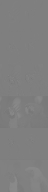

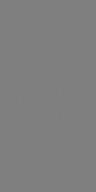

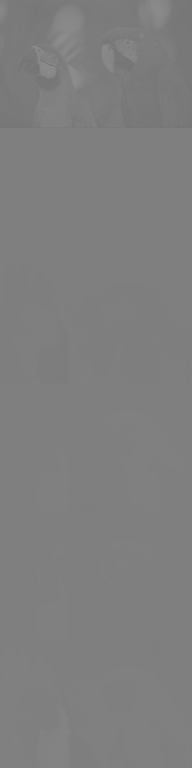

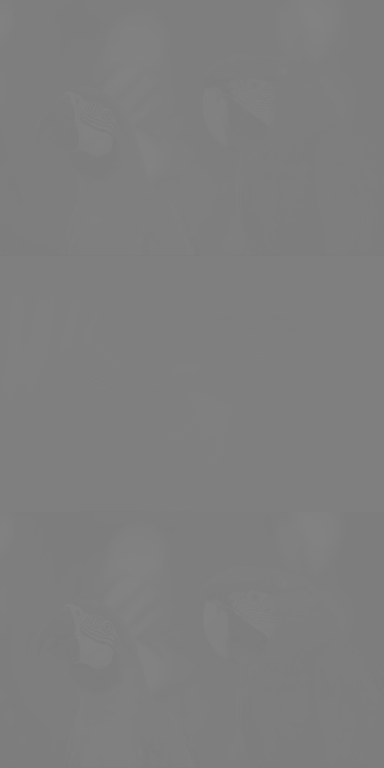

PSNR=35.19 dB (21ch)


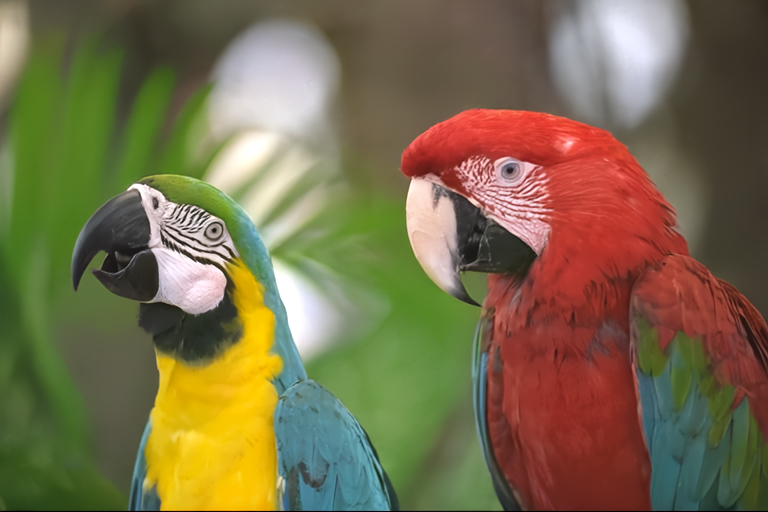

In [6]:
img = prepare_image(dataset[22]['image'], max_ps)
x = pil_to_tensor(img.convert("RGB")).to(torch.float).to(device).unsqueeze(0) / 127.5 - 1.0
x_in = srgb_to_linear(x) if getattr(config, 'linear_input', False) else x
n_pixels = x.shape[2] * x.shape[3]

# 1. Encode
with torch.inference_mode():
    latents = merged.encode(x_in)
    latents_q = [z.round().clamp(-127, 127).to(torch.int8) for z in latents]

# 2. Compression ratio
bpp = compute_bpp(latents_q, n_pixels)
print(f"bpp={bpp:.4f}  CR={24/bpp:.2f}")

# 3. Display latents per scale
for z in latents_q:
    z_2d = z[0].reshape(z.shape[1] * z.shape[2], z.shape[3])
    display(to_pil_image((z_2d.long() + 127).to(torch.uint8)))

# 4. Decode
with torch.inference_mode():
    xhat = merged.decode(latents_q).clamp(-1, 1)
x_01 = x / 2 + 0.5
xhat_01 = xhat / 2 + 0.5

# 5. PSNR
psnr = -10 * torch.nn.functional.mse_loss(x_01, xhat_01).log10().item()
print(f"PSNR={psnr:.2f} dB ({n_trained}ch)")

# 6. Display reconstruction
display(to_pil_image(xhat_01[0].cpu().clamp(0, 1)))

## Variable-rate: truncated channel reconstruction

For variable-rate coding, transmit only the first `n_ch` channels. Each channel count has its own decoder snapshot.

CR=5436.17  PSNR=17.04 dB (1ch)


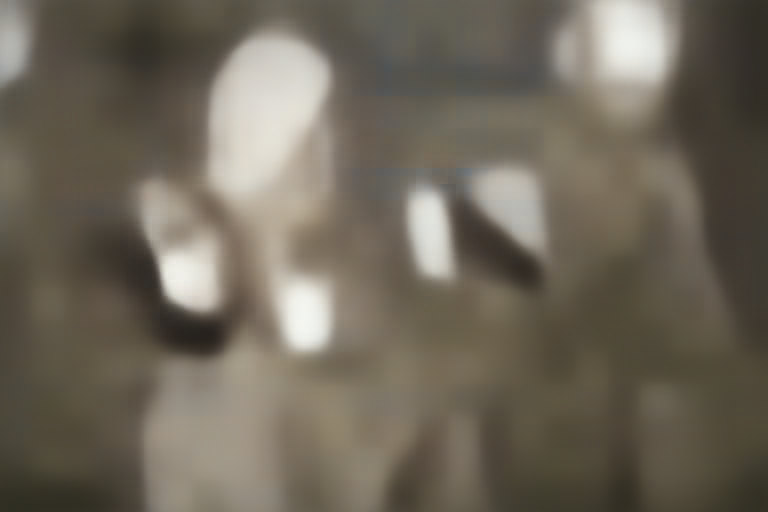

CR=3490.08  PSNR=20.65 dB (2ch)


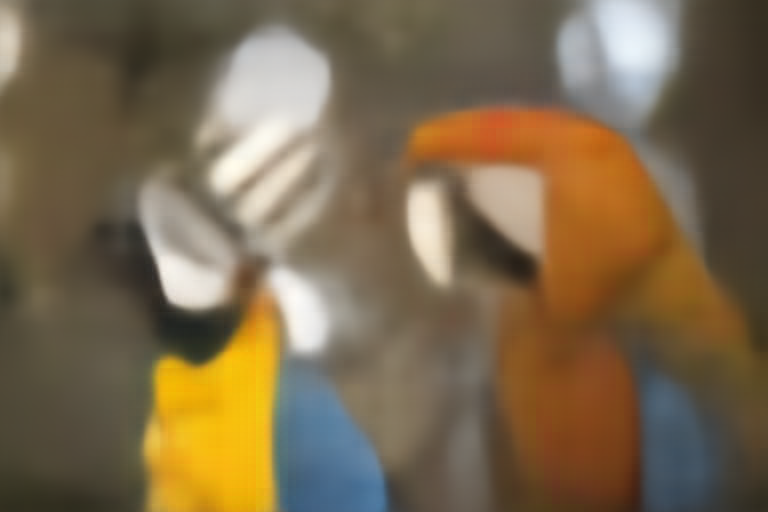

CR=2699.42  PSNR=22.93 dB (3ch)


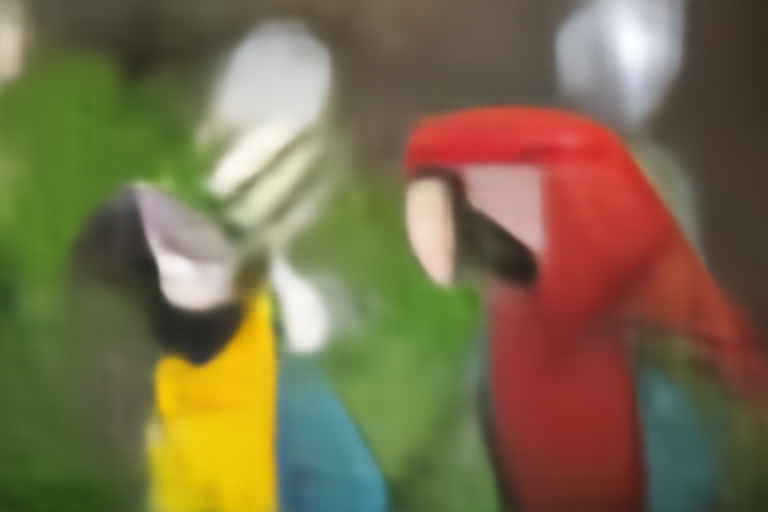

CR=1024.89  PSNR=24.98 dB (6ch)


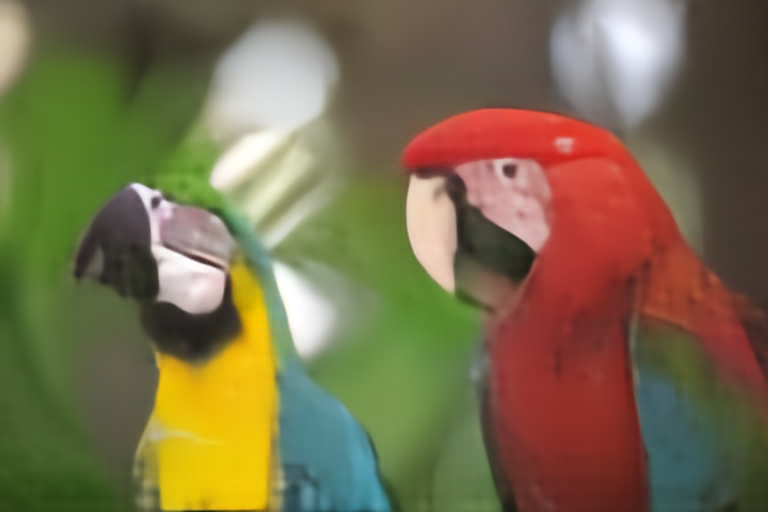

CR=403.71  PSNR=28.14 dB (12ch)


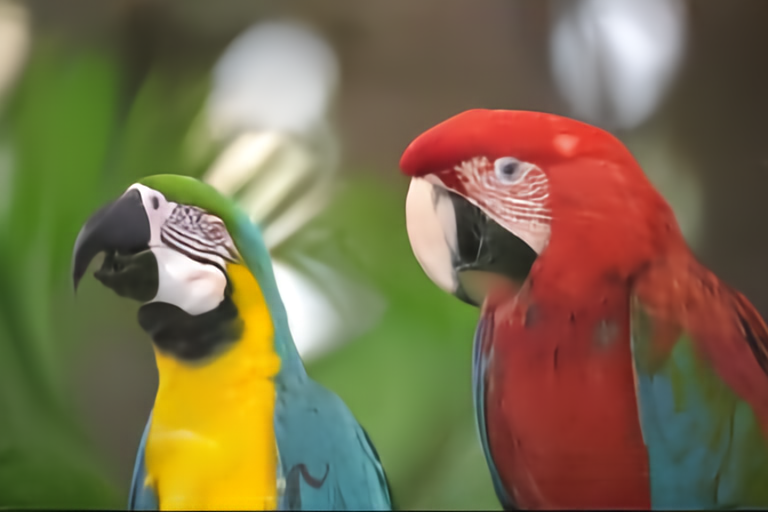

CR=116.16  PSNR=32.09 dB (15ch)


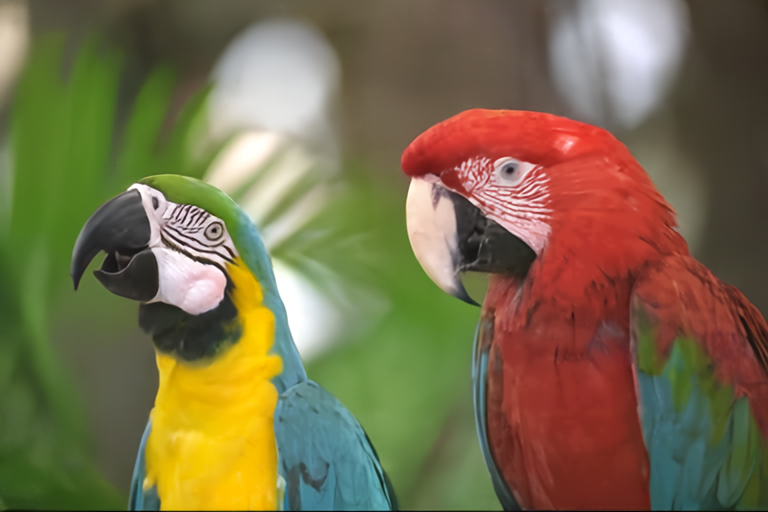

CR=36.57  PSNR=35.19 dB (21ch)


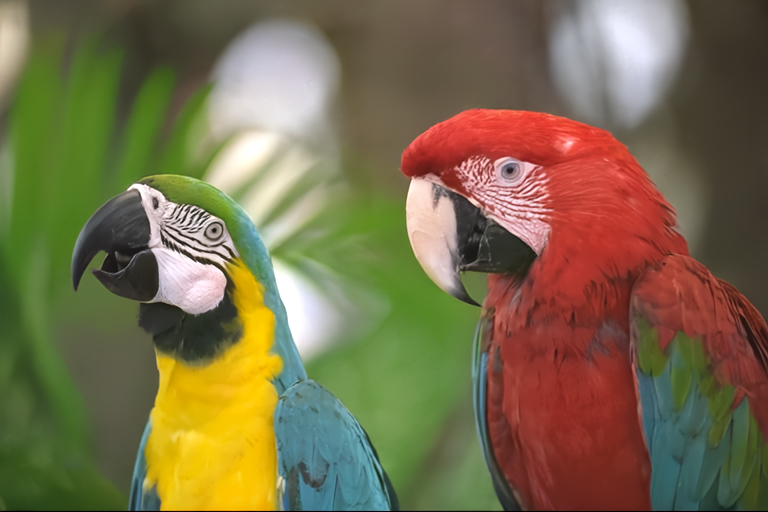

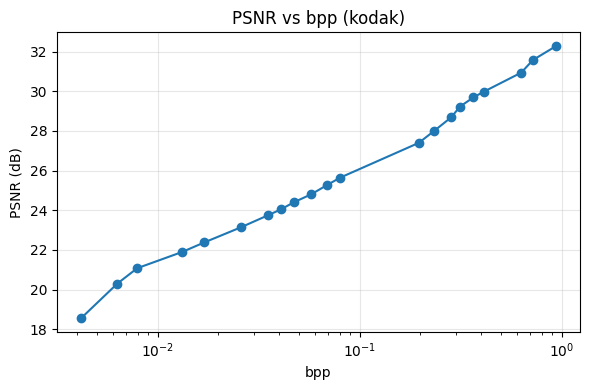


Kodak average (21ch):
  [ch0] bpp=0.0042  CR=5767.27  PSNR=18.54 dB
  [ch1] bpp=0.0063  CR=3802.25  PSNR=20.30 dB
  [ch2] bpp=0.0079  CR=3030.24  PSNR=21.08 dB
  [ch3] bpp=0.0132  CR=1817.76  PSNR=21.90 dB
  [ch4] bpp=0.0170  CR=1412.33  PSNR=22.38 dB
  [ch5] bpp=0.0257  CR=932.65  PSNR=23.13 dB
  [ch6] bpp=0.0351  CR=684.73  PSNR=23.74 dB
  [ch7] bpp=0.0408  CR=587.57  PSNR=24.05 dB
  [ch8] bpp=0.0471  CR=509.37  PSNR=24.40 dB
  [ch9] bpp=0.0577  CR=416.15  PSNR=24.81 dB
  [ch10] bpp=0.0690  CR=347.68  PSNR=25.27 dB
  [ch11] bpp=0.0800  CR=299.89  PSNR=25.64 dB
  [ch12] bpp=0.1963  CR=122.27  PSNR=27.40 dB
  [ch13] bpp=0.2327  CR=103.16  PSNR=27.98 dB
  [ch14] bpp=0.2848  CR=84.28  PSNR=28.69 dB
  [ch15] bpp=0.3140  CR=76.44  PSNR=29.22 dB
  [ch16] bpp=0.3660  CR=65.57  PSNR=29.69 dB
  [ch17] bpp=0.4119  CR=58.26  PSNR=29.98 dB
  [ch18] bpp=0.6319  CR=37.98  PSNR=30.94 dB
  [ch19] bpp=0.7216  CR=33.26  PSNR=31.57 dB
  [ch20] bpp=0.9414  CR=25.50  PSNR=32.28 dB


In [7]:
from compressors.frappe.evaluate import validate

for n_ch in [1,2,3,6,12,15,21]:
    partial = load_progressive_model(weights, config, n_ch, device)
    
    with torch.inference_mode():
        latents_pq = [z.round().clamp(-127, 127).to(torch.int8) for z in partial.encode(x_in)]
        xhat_p = partial.decode(latents_pq).clamp(-1, 1)
    
    bpp_p = compute_bpp(latents_pq, n_pixels)
    psnr_p = -10 * torch.nn.functional.mse_loss(x_01, xhat_p / 2 + 0.5).log10().item()
    print(f"CR={24/bpp_p:.2f}  PSNR={psnr_p:.2f} dB ({n_ch}ch)")
    display(to_pil_image((xhat_p[0] / 2 + 0.5).cpu().clamp(0, 1)))

rd_points = []
for n_ch in range(1, n_trained + 1):
    model = load_progressive_model(weights, config, n_ch, device)
    psnr, cr = validate(model, device, dataset, config)
    rd_points.append((24.0 / cr, psnr))
    del model
    torch.cuda.empty_cache()

plt.figure(figsize=(6, 4))
plt.semilogx([p[0] for p in rd_points], [p[1] for p in rd_points], 'o-')
plt.xlabel('bpp')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs bpp (kodak)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKodak average ({n_trained}ch):")
for i, (bpp, psnr) in enumerate(rd_points):
    print(f"  [ch{i}] bpp={bpp:.4f}  CR={24/bpp:.2f}  PSNR={psnr:.2f} dB")